In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [3]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [4]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [5]:
cat_cols = df.select_dtypes(
    include=['object','string']).columns

for col in cat_cols:
    df[col]= df[col].fillna(
        df[col].mode()[0]
    )

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='SalePrice', ylabel='Count'>

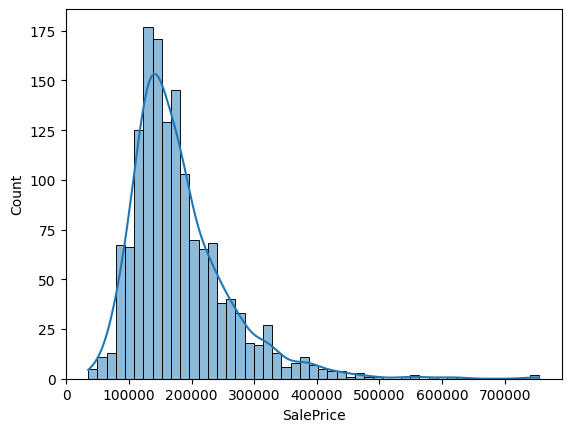

In [7]:
sns.histplot(
    df['SalePrice'],
    kde=True
)

<Axes: >

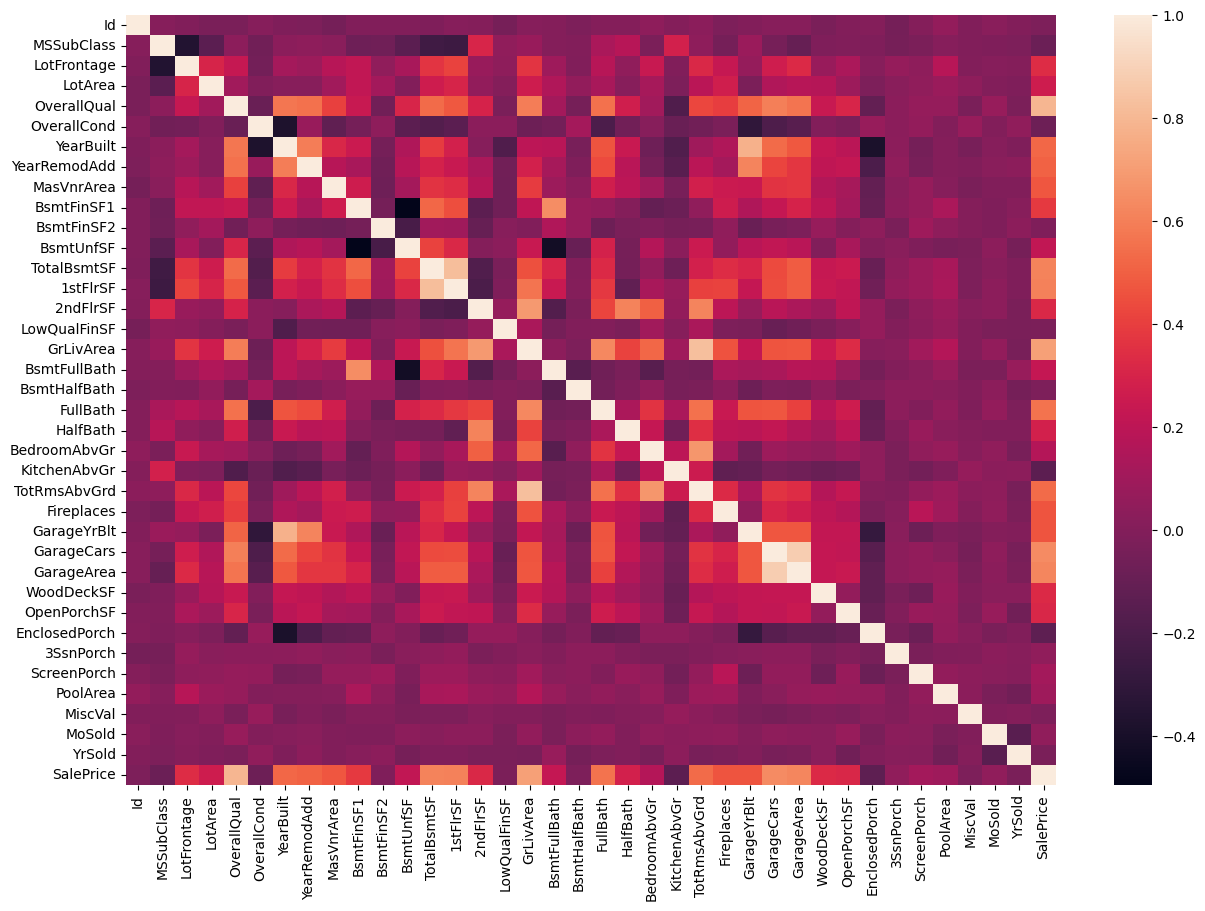

In [8]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True)
)

In [9]:
corr = df.corr(
    numeric_only=True
)['SalePrice']

corr.sort_values(
    ascending=False
).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [10]:
df['HouseAge'] = (
    2026 - df['YearBuilt']
)

In [11]:
df['TotalArea'] = (
    df['GrLivArea']
    + df['TotalBsmtSF']
)

In [12]:
df['TotalBath'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
)

In [13]:
import numpy as np

df['SalePrice'] = np.log1p(
    df['SalePrice']
)

In [14]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [15]:
X = df.drop(
    'SalePrice',
    axis=1
)

y = df['SalePrice']

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train,y_train)

Ridge()

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [20]:
import pickle

pickle.dump(
    rf,
    open("random_forest.pkl", "wb")
)

In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05
)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [22]:
pickle.dump(
    xgb,
    open("xgboost.pkl", "wb")
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

In [25]:
from sklearn.metrics import r2_score

In [26]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [27]:
lr_r2 = r2_score(y_test, lr_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
rf_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

In [28]:
import streamlit as st
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Random Forest', 'XGBoost'],
    'R2 Score': [lr_r2, ridge_r2, rf_r2, xgb_r2]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.756576
1              Ridge  0.899244
2      Random Forest  0.880449
3            XGBoost  0.880988


In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

          Feature  Importance
4     OverallQual    0.422243
38      TotalArea    0.336413
26     GarageCars    0.014618
16      GrLivArea    0.013607
27     GarageArea    0.012942
7    YearRemodAdd    0.012897
3         LotArea    0.011891
9      BsmtFinSF1    0.011104
192  CentralAir_Y    0.010183
37       HouseAge    0.009609


In [32]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top Price Factors:")
print(feature_importance.head(10))

Top Price Factors:
          Feature  Importance
4     OverallQual    0.422243
38      TotalArea    0.336413
26     GarageCars    0.014618
16      GrLivArea    0.013607
27     GarageArea    0.012942
7    YearRemodAdd    0.012897
3         LotArea    0.011891
9      BsmtFinSF1    0.011104
192  CentralAir_Y    0.010183
37       HouseAge    0.009609


In [33]:
top4 = feature_importance.head(4)

print("Top Price Factors:")
for feature in top4['Feature']:
    print("-", feature)

Top Price Factors:
- OverallQual
- TotalArea
- GarageCars
- GrLivArea
